In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import sys
sys.path.append('/kaggle/input/datasets/zxcdfg/dataset-dt1')

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [14]:
from utils import weighted_pearson_correlation

In [4]:
df = pd.read_parquet('/kaggle/input/datasets/zxcdfg/dataset-dt1/train.parquet')
df_valid = pd.read_parquet('/kaggle/input/datasets/zxcdfg/dataset-dt1/valid.parquet')

In [36]:
import numpy as np
import lightgbm as lgb

# Base columns
base_cols = (
    [f"p{i}" for i in range(12)] +
    [f"v{i}" for i in range(12)] +
    [f"dp{i}" for i in range(3)] +
    [f"dv{i}" for i in range(3)]
)

# Cumulative features (sequence-wise)
for col in base_cols:
    df[f"cum_{col}"] = df.groupby("seq_ix")[col].cumsum()

In [37]:
import numpy as np
import pandas as pd

# Base feature columns
base_cols = (
    [f"p{i}" for i in range(12)] +
    [f"v{i}" for i in range(12)] +
    [f"dp{i}" for i in range(3)] +
    [f"dv{i}" for i in range(3)]
)

# Create cumulative features sequence-wise
for col in base_cols:
    df[f"cum_{col}"] = df.groupby("seq_ix")[col].cumsum()

print("Cumulative columns created.")

Cumulative columns created.


In [6]:
upper = np.percentile(df["t1"], 85)
lower = np.percentile(df["t1"], 15)

df["t1_label"] = np.where(
    df["t1"] >= upper, 1,
    np.where(df["t1"] <= lower, 0, -1)  # -1 = neutral
)

print(df["t1_label"].value_counts())

t1_label
-1    7504341
 1    1608458
 0    1608201
Name: count, dtype: int64


In [38]:
feature_cols = base_cols + [f"cum_{col}" for col in base_cols]

X = df[feature_cols].values.astype(np.float32)
y = df["t1_label"].values

KeyError: 't1_label'

In [8]:
extreme_mask = y != -1

X_extreme = X[extreme_mask]
y_extreme = y[extreme_mask]

train_data = lgb.Dataset(X_extreme, label=y_extreme)

params = {
    "objective": "binary",
    "metric": "binary_logloss",
    "learning_rate": 0.05,
    "num_leaves": 64,
    "max_depth": -1,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "verbose": -1,
    "num_threads": -1
}

model = lgb.train(
    params,
    train_data,
    num_boost_round=200
)

In [13]:
probs = model.predict(X)



In [38]:
threshold = 0.60  # tune later

pred = np.full(len(df), -1)  # default neutral

pred[probs > threshold] = 1
pred[probs < (1 - threshold)] = 0

df["pred_label"] = pred

In [39]:
extreme_errors = df[
    ((df["t1_label"] == 1) & (df["pred_label"] == 0)) |
    ((df["t1_label"] == 0) & (df["pred_label"] == 1))
]

print("Extreme misclassifications:", len(extreme_errors))

Extreme misclassifications: 115016


In [40]:
recall_pos = (
    (df["t1_label"] == 1) &
    (df["pred_label"] == 1)
).sum() / (df["t1_label"] == 1).sum()

print("Recall High Positive:", recall_pos)

Recall High Positive: 0.113787242190968


In [41]:
recall_neg = (
    (df["t1_label"] == 0) &
    (df["pred_label"] == 0)
).sum() / (df["t1_label"] == 0).sum()

print("Recall High Negative:", recall_neg)

Recall High Negative: 0.09975121269045349


In [42]:
x = 100

In [43]:
df["t1_pred"] = np.where(
    df["pred_label"] == 1, x,
    np.where(df["pred_label"] == 0, -x, 0.0)
)

In [44]:
weighted_pearson_correlation(df['t1'], df['t1_pred'])

0.14424814027549743

Best threshold: 0.54
Best weighted pearson: 0.17063050267508326


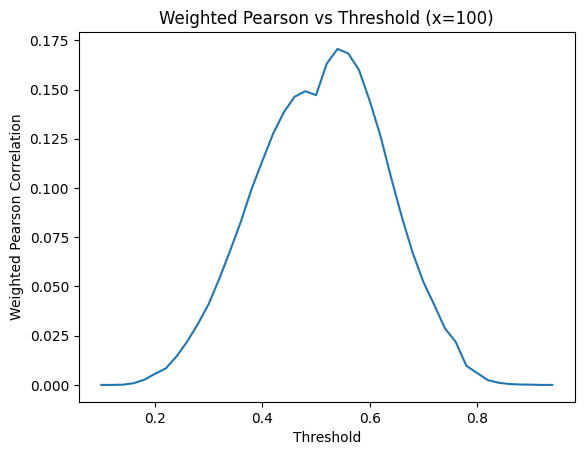

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Keep x fixed
x = 100

thresholds = np.arange(0.10, 0.95, 0.02)
scores = []

for threshold in thresholds:

    # Default neutral
    pred = np.full(len(df), -1)

    pred[probs > threshold] = 1
    pred[probs < (1 - threshold)] = 0

    # Convert to t1_pred
    t1_pred = np.where(
        pred == 1, x,
        np.where(pred == 0, -x, 0.0)
    )

    score = weighted_pearson_correlation(
        df["t1"].values,
        t1_pred
    )

    scores.append(score)

# Convert to array
scores = np.array(scores)

# Find best threshold
best_idx = np.argmax(scores)
best_threshold = thresholds[best_idx]
best_score = scores[best_idx]

print("Best threshold:", best_threshold)
print("Best weighted pearson:", best_score)

# Plot
plt.figure()
plt.plot(thresholds, scores)
plt.xlabel("Threshold")
plt.ylabel("Weighted Pearson Correlation")
plt.title("Weighted Pearson vs Threshold (x=100)")
plt.show()

Best validation threshold: 0.54
Best validation weighted pearson: 0.05561321228529155


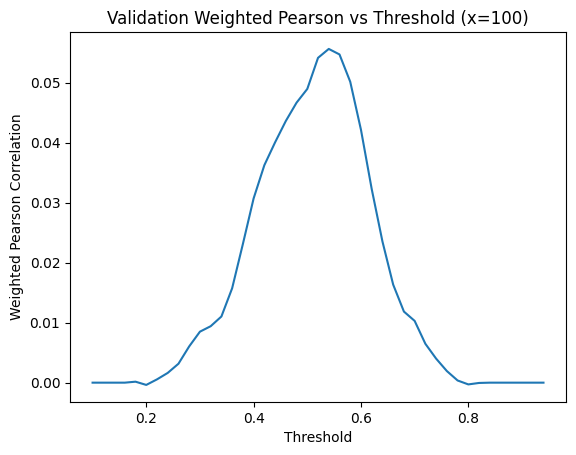

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# -------- 1. Create cumulative features in df_valid --------
for col in base_cols:
    df_valid[f"cum_{col}"] = df_valid.groupby("seq_ix")[col].cumsum()

# -------- 2. Build feature matrix --------
X_valid = df_valid[feature_cols].values.astype(np.float32)

# -------- 3. Predict probabilities using trained model --------
probs_valid = model.predict(X_valid)

# -------- 4. Sweep thresholds --------
x = 100
thresholds = np.arange(0.1, 0.95, 0.02)
scores_valid = []

for threshold in thresholds:

    pred = np.full(len(df_valid), -1)

    pred[probs_valid > threshold] = 1
    pred[probs_valid < (1 - threshold)] = 0

    t1_pred_valid = np.where(
        pred == 1, x,
        np.where(pred == 0, -x, 0.0)
    )

    score = weighted_pearson_correlation(
        df_valid["t1"].values,
        t1_pred_valid
    )

    scores_valid.append(score)

scores_valid = np.array(scores_valid)

# -------- 5. Best threshold on validation --------
best_idx = np.argmax(scores_valid)
best_threshold = thresholds[best_idx]
best_score = scores_valid[best_idx]

print("Best validation threshold:", best_threshold)
print("Best validation weighted pearson:", best_score)

# -------- 6. Plot --------
plt.figure()
plt.plot(thresholds, scores_valid)
plt.xlabel("Threshold")
plt.ylabel("Weighted Pearson Correlation")
plt.title("Validation Weighted Pearson vs Threshold (x=100)")
plt.show()

In [4]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Define feature groups
base_cols = (
    [f"p{i}" for i in range(12)] +
    [f"v{i}" for i in range(12)] +
    [f"dp{i}" for i in range(3)] +
    [f"dv{i}" for i in range(3)]
)
df['p5-p11'] = df['p5'] - df['p11']
df['p4-p11'] = df['p4'] - df['p11']
df['dp0-dp2'] = df['dp0'] - df['dp2']
df['p1-p7'] = df['p1'] - df['p7']

df_valid['p5-p11'] = df_valid['p5'] - df_valid['p11']
df_valid['p4-p11'] = df_valid['p4'] - df_valid['p11']
df_valid['dp0-dp2'] = df_valid['dp0'] - df_valid['dp2']
df_valid['p1-p7'] = df_valid['p1'] - df_valid['p7']
engineered_cols = (
    ['p5-p11', 'p4-p11', 'dp0-dp2', 'p1-p7']    # p4–p11
)

feature_cols = list(set(base_cols + engineered_cols))

In [6]:
class SequenceDataset(Dataset):
    def __init__(self, df, feature_cols):
        self.groups = []
        self.targets = []
        
        for _, g in df.groupby("seq_ix"):
            self.groups.append(
                torch.tensor(g[feature_cols].values, dtype=torch.float32)
            )
            self.targets.append(
                torch.tensor(g["t1"].values, dtype=torch.float32)
            )

    def __len__(self):
        return len(self.groups)

    def __getitem__(self, idx):
        return self.groups[idx], self.targets[idx]

In [7]:
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out)
        return out.squeeze(-1)

In [8]:
dataset = SequenceDataset(df, feature_cols)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=lambda batch: batch  # variable length
)

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GRUModel(input_size=len(feature_cols)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

epochs = 5

for epoch in range(epochs):
    total_loss = 0
    
    for batch in loader:
        optimizer.zero_grad()
        batch_loss = 0
        
        for x_seq, y_seq in batch:
            x_seq = x_seq.unsqueeze(0).to(device)
            y_seq = y_seq.unsqueeze(0).to(device)
            
            pred = model(x_seq)
            loss = criterion(pred, y_seq)
            batch_loss += loss
        
        batch_loss.backward()
        optimizer.step()
        
        total_loss += batch_loss.item()
    
    print(f"Epoch {epoch+1} Loss: {total_loss:.4f}")

Epoch 1 Loss: 13554.6654
Epoch 2 Loss: 13496.5962
Epoch 3 Loss: 13472.3080
Epoch 4 Loss: 13459.6688
Epoch 5 Loss: 13448.3861


In [12]:
valid_dataset = SequenceDataset(df_valid, feature_cols)

model.eval()
all_preds = []

with torch.no_grad():
    for x_seq, _ in valid_dataset:
        x_seq = x_seq.unsqueeze(0).to(device)
        pred = model(x_seq)
        all_preds.append(pred.squeeze(0).cpu().numpy())

df_valid["t1_pred"] = np.concatenate(all_preds)

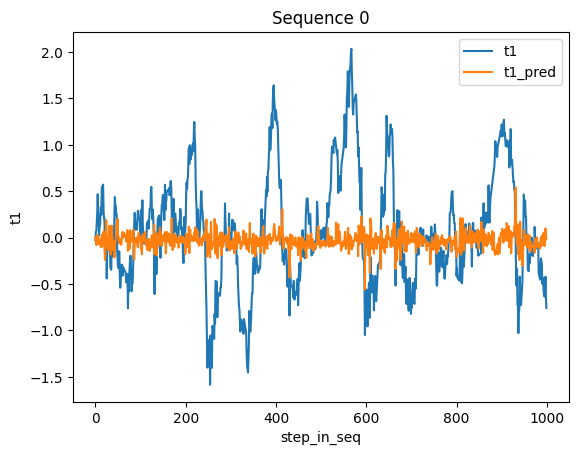

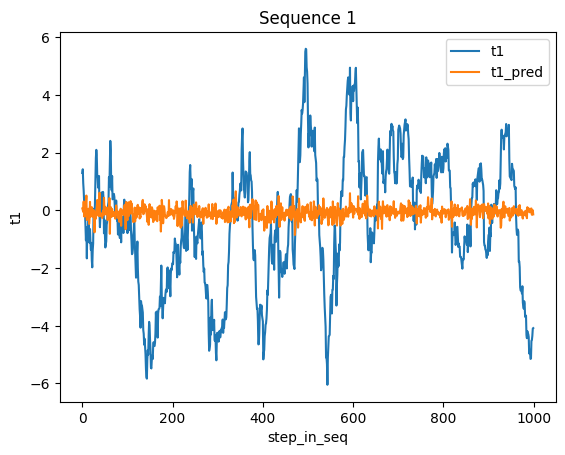

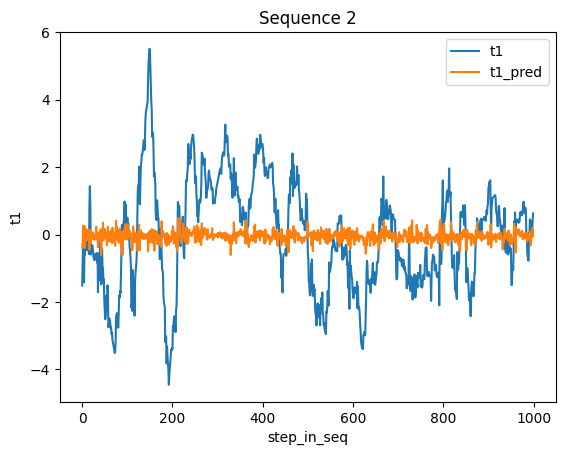

In [14]:
import matplotlib.pyplot as plt

# Pick first 3 sequences (change if you want)
seq_list = df_valid["seq_ix"].unique()[:3]

for seq in seq_list:
    
    g = df_valid[df_valid["seq_ix"] == seq]
    
    plt.figure()
    plt.plot(g["step_in_seq"].values, g["t1"].values)
    plt.plot(g["step_in_seq"].values, g["t1_pred"].values)
    
    plt.xlabel("step_in_seq")
    plt.ylabel("t1")
    plt.title(f"Sequence {seq}")
    plt.legend(["t1", "t1_pred"])
    plt.show()

In [15]:
import numpy as np

upper = np.percentile(df["t1"], 85)
lower = np.percentile(df["t1"], 15)

df["t1_label"] = np.where(
    df["t1"] >= upper, 2,       # +1 mapped to class 2
    np.where(df["t1"] <= lower, 0, 1)  # -1 -> 0, neutral -> 1
)

In [16]:
import torch
from torch.utils.data import Dataset

class SequenceDataset(Dataset):
    def __init__(self, df, feature_cols):
        self.groups = []
        self.targets = []
        
        for _, g in df.groupby("seq_ix"):
            self.groups.append(
                torch.tensor(g[feature_cols].values, dtype=torch.float32)
            )
            self.targets.append(
                torch.tensor(g["t1_label"].values, dtype=torch.long)
            )

    def __len__(self):
        return len(self.groups)

    def __getitem__(self, idx):
        return self.groups[idx], self.targets[idx]

In [17]:
import torch.nn as nn

class GRUClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_classes=3):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out)
        return out

In [19]:
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset = SequenceDataset(df, feature_cols)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

model = GRUClassifier(len(feature_cols)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 2

for epoch in range(epochs):
    total_loss = 0
    
    for x_seq, y_seq in loader:
        x_seq = x_seq.to(device)
        y_seq = y_seq.to(device)
        
        optimizer.zero_grad()
        
        logits = model(x_seq)
        loss = criterion(
            logits.view(-1, 3),
            y_seq.view(-1)
        )
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1} Loss: {total_loss:.4f}")

Epoch 1 Loss: 254.3465
Epoch 2 Loss: 248.9426


In [23]:
# Use SAME thresholds from training
df_valid["t1_label"] = np.where(
    df_valid["t1"] >= upper, 2,
    np.where(df_valid["t1"] <= lower, 0, 1)
)

In [24]:
valid_dataset = SequenceDataset(df_valid, feature_cols)

model.eval()
all_preds = []

with torch.no_grad():
    for x_seq, _ in valid_dataset:
        x_seq = x_seq.unsqueeze(0).to(device)
        logits = model(x_seq)
        preds = torch.argmax(logits, dim=-1)
        all_preds.append(preds.squeeze(0).cpu().numpy())

df_valid["label_pred"] = np.concatenate(all_preds)

In [25]:
import numpy as np

y_true = df_valid["t1_label"].values
y_pred = df_valid["label_pred"].values

# -------- Recall High Positive (class 2) --------
recall_pos = (
    (y_true == 2) & (y_pred == 2)
).sum() / (y_true == 2).sum()

# -------- Recall High Negative (class 0) --------
recall_neg = (
    (y_true == 0) & (y_pred == 0)
).sum() / (y_true == 0).sum()

# -------- Cross Mistakes (Extreme Flip) --------
cross_errors = (
    ((y_true == 2) & (y_pred == 0)) |
    ((y_true == 0) & (y_pred == 2))
).sum()

print("Recall High Positive:", recall_pos)
print("Recall High Negative:", recall_neg)
print("Extreme Cross Mistakes:", cross_errors)

Recall High Positive: 0.291439004708561
Recall High Negative: 0.15552454301436416
Extreme Cross Mistakes: 142600


In [27]:
df_valid["signed_label"] = np.where(
    df_valid["t1_label"] == 2, 1,
    np.where(df_valid["t1_label"] == 0, -1, 0)
)

In [28]:
df_valid["signed_pred"] = np.where(
    df_valid["label_pred"] == 2, 1,
    np.where(df_valid["label_pred"] == 0, -1, 0)
)

In [29]:
y_true = df_valid["signed_label"].values
y_pred = df_valid["signed_pred"].values

recall_pos = (
    (y_true == 1) & (y_pred == 1)
).sum() / (y_true == 1).sum()

recall_neg = (
    (y_true == -1) & (y_pred == -1)
).sum() / (y_true == -1).sum()

cross_errors = (
    ((y_true == 1) & (y_pred == -1)) |
    ((y_true == -1) & (y_pred == 1))
).sum()

print("Recall High Positive:", recall_pos)
print("Recall High Negative:", recall_neg)
print("Extreme Cross Mistakes:", cross_errors)

Recall High Positive: 0.291439004708561
Recall High Negative: 0.15552454301436416
Extreme Cross Mistakes: 142600


In [30]:
weighted_pearson_correlation(df_valid['t1'], df_valid['signed_pred'])

0.055571263730981674

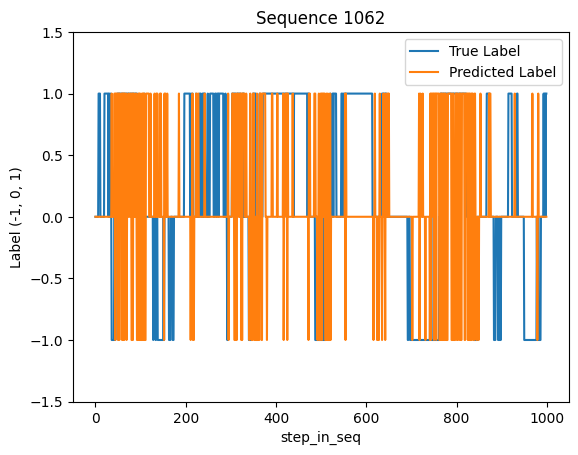

In [32]:
import matplotlib.pyplot as plt

# Pick some sequences to visualize
seq_list = [1062]  # change number if needed

for seq in seq_list:
    
    g = df_valid[df_valid["seq_ix"] == seq]
    
    plt.figure()
    
    plt.plot(
        g["step_in_seq"].values,
        g["signed_label"].values
    )
    
    plt.plot(
        g["step_in_seq"].values,
        g["signed_pred"].values
    )
    
    plt.xlabel("step_in_seq")
    plt.ylabel("Label (-1, 0, 1)")
    plt.title(f"Sequence {seq}")
    plt.legend(["True Label", "Predicted Label"])
    plt.ylim(-1.5, 1.5)
    plt.show()

In [33]:
import numpy as np

upper = np.percentile(df["t0"], 85)
lower = np.percentile(df["t0"], 15)

# Train labels
df["t0_label"] = np.where(
    df["t0"] >= upper, 2,
    np.where(df["t0"] <= lower, 0, 1)
)

# Validation labels (same thresholds)
df_valid["t0_label"] = np.where(
    df_valid["t0"] >= upper, 2,
    np.where(df_valid["t0"] <= lower, 0, 1)
)

print(df["t0_label"].value_counts())

t0_label
1    7352348
0    1715593
2    1653059
Name: count, dtype: int64


In [34]:
import torch
from torch.utils.data import Dataset

class SequenceDataset(Dataset):
    def __init__(self, df, feature_cols, label_col):
        self.groups = []
        self.targets = []
        
        for _, g in df.groupby("seq_ix"):
            self.groups.append(
                torch.tensor(g[feature_cols].values, dtype=torch.float32)
            )
            self.targets.append(
                torch.tensor(g[label_col].values, dtype=torch.long)
            )

    def __len__(self):
        return len(self.groups)

    def __getitem__(self, idx):
        return self.groups[idx], self.targets[idx]

In [35]:
import torch.nn as nn

class GRUClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_classes=3):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out)
        return out

In [37]:
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_dataset = SequenceDataset(df, feature_cols, "t0_label")
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

model = GRUClassifier(len(feature_cols)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 1

for epoch in range(epochs):
    total_loss = 0
    
    for x_seq, y_seq in train_loader:
        x_seq = x_seq.to(device)
        y_seq = y_seq.to(device)
        
        optimizer.zero_grad()
        
        logits = model(x_seq)
        loss = criterion(
            logits.view(-1, 3),
            y_seq.view(-1)
        )
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1} Loss: {total_loss:.4f}")

Epoch 1 Loss: 272.5505


In [38]:
valid_dataset = SequenceDataset(df_valid, feature_cols, "t0_label")

model.eval()
all_preds = []

with torch.no_grad():
    for x_seq, _ in valid_dataset:
        x_seq = x_seq.unsqueeze(0).to(device)
        logits = model(x_seq)
        preds = torch.argmax(logits, dim=-1)
        all_preds.append(preds.squeeze(0).cpu().numpy())

df_valid["t0_label_pred"] = np.concatenate(all_preds)

In [39]:
df_valid["t0_signed_true"] = np.where(
    df_valid["t0_label"] == 2, 1,
    np.where(df_valid["t0_label"] == 0, -1, 0)
)

df_valid["t0_signed_pred"] = np.where(
    df_valid["t0_label_pred"] == 2, 1,
    np.where(df_valid["t0_label_pred"] == 0, -1, 0)
)

In [40]:
y_true = df_valid["t0_signed_true"].values
y_pred = df_valid["t0_signed_pred"].values

recall_pos = (
    (y_true == 1) & (y_pred == 1)
).sum() / (y_true == 1).sum()

recall_neg = (
    (y_true == -1) & (y_pred == -1)
).sum() / (y_true == -1).sum()

cross_errors = (
    ((y_true == 1) & (y_pred == -1)) |
    ((y_true == -1) & (y_pred == 1))
).sum()

print("Recall High Positive:", recall_pos)
print("Recall High Negative:", recall_neg)
print("Extreme Cross Mistakes:", cross_errors)

Recall High Positive: 0.036420844738314355
Recall High Negative: 0.23698826576202986
Extreme Cross Mistakes: 28171


In [43]:
weighted_pearson_correlation(df_valid['t0_signed_true'], df_valid['t0'])

0.834544861713814

In [5]:
import numpy as np

df["dt1"] = df.groupby("seq_ix")["t1"].diff()
df_valid["dt1"] = df_valid.groupby("seq_ix")["t1"].diff()

In [6]:
from sklearn.linear_model import Ridge

# Remove first-step NaNs
mask = ~df["dt1"].isna()

X_dt1 = df.loc[mask, feature_cols].values
y_dt1 = df.loc[mask, "dt1"].values

dt1_model = Ridge(alpha=1.0)
dt1_model.fit(X_dt1, y_dt1)

# Predict on validation
df_valid["dt1_pred"] = dt1_model.predict(
    df_valid[feature_cols].values
)

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [8]:
class SeqDataset(Dataset):
    def __init__(self, df, feature_cols, target_col):
        self.X = []
        self.y = []
        for _, g in df.groupby("seq_ix"):
            self.X.append(torch.tensor(
                g[feature_cols].values,
                dtype=torch.float32
            ))
            self.y.append(torch.tensor(
                g[target_col].values,
                dtype=torch.float32
            ))

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [10]:
class GRUReg(nn.Module):
    def __init__(self, input_size, hidden=64):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out)
        return out.squeeze(-1)

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_dataset = SeqDataset(df, feature_cols, "t1")
loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

model = GRUReg(len(feature_cols)).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for epoch in range(1):
    total = 0
    for X_seq, y_seq in loader:
        X_seq = X_seq.to(device)
        y_seq = y_seq.to(device)

        opt.zero_grad()
        pred = model(X_seq)
        loss = loss_fn(pred, y_seq)
        loss.backward()
        opt.step()

        total += loss.item()

    print("Epoch", epoch+1, "Loss", total)

Epoch 1 Loss 426.71106684207916


In [13]:
valid_dataset = SeqDataset(df_valid, feature_cols, "t1")

model.eval()
gru_preds = []

with torch.no_grad():
    for X_seq, _ in valid_dataset:
        X_seq = X_seq.unsqueeze(0).to(device)
        pred = model(X_seq)
        gru_preds.append(pred.squeeze(0).cpu().numpy())

df_valid["gru_pred"] = np.concatenate(gru_preds)

In [28]:
anchor_window = 10
beta = 0.0002

# Create anchor block index
df_valid["anchor_block"] = (
    df_valid["step_in_seq"] // anchor_window
)

# Cumulative dt1 within each (seq, anchor block)
df_valid["running_dt"] = (
    df_valid
    .groupby(["seq_ix", "anchor_block"])["dt1_pred"]
    .cumsum()
)

# Final fused prediction
df_valid["t1_fused"] = (
    df_valid["gru_pred"]
    + beta * df_valid["running_dt"]
)

In [29]:
print("GRU only:",
      weighted_pearson_correlation(
          df_valid["t1"], df_valid["gru_pred"]
      ))

print("Fused:",
      weighted_pearson_correlation(
          df_valid["t1"], df_valid["t1_fused"]
      ))

GRU only: 0.11927692181194967
Fused: 0.1192571743143186


In [30]:
# Train
df["t1_7"] = (
    df.groupby("seq_ix")["t1"]
      .transform(lambda x: x - x.shift(7))
)

# Validation
df_valid["t1_7"] = (
    df_valid.groupby("seq_ix")["t1"]
      .transform(lambda x: x - x.shift(7))
)

In [31]:
import numpy as np
import torch
from torch.utils.data import Dataset

class SeqDatasetT7(Dataset):
    def __init__(self, df, feature_cols, target_col):
        self.X = []
        self.y = []

        for _, g in df.groupby("seq_ix"):
            
            target = g[target_col].values
            mask = ~np.isnan(target)

            if mask.sum() == 0:
                continue

            self.X.append(
                torch.tensor(
                    g[feature_cols].values[mask],
                    dtype=torch.float32
                )
            )

            self.y.append(
                torch.tensor(
                    target[mask],
                    dtype=torch.float32
                )
            )

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [33]:
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_dataset = SeqDatasetT7(df, feature_cols, "t1_7")
loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

model = GRUReg(len(feature_cols)).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for epoch in range(2):
    total = 0

    for X_seq, y_seq in loader:
        X_seq = X_seq.to(device)
        y_seq = y_seq.to(device)

        opt.zero_grad()
        pred = model(X_seq)
        loss = loss_fn(pred, y_seq)
        loss.backward()
        opt.step()

        total += loss.item()

    print("Epoch", epoch+1, "Loss", total)

Epoch 1 Loss 40.853507136926055
Epoch 2 Loss 25.836233008652925


In [34]:
valid_dataset = SeqDatasetT7(df_valid, feature_cols, "t1_7")

model.eval()
all_preds = []

with torch.no_grad():
    for X_seq, _ in valid_dataset:
        X_seq = X_seq.unsqueeze(0).to(device)
        pred = model(X_seq)
        all_preds.append(pred.squeeze(0).cpu().numpy())

df_valid.loc[
    df_valid["t1_7"].notna(),
    "t1_7_pred"
] = np.concatenate(all_preds)

In [35]:
import numpy as np
from sklearn.linear_model import Ridge

# Mask valid targets
mask = ~df["t1_7"].isna()

X_train = df.loc[mask, feature_cols].values
y_train = df.loc[mask, "t1_7"].values

lin_model = Ridge(alpha=1.0)
lin_model.fit(X_train, y_train)

print("Linear model trained.")

Linear model trained.


In [36]:
# Predict everywhere (we'll mask later)
df_valid["t1_7_pred_lin"] = lin_model.predict(
    df_valid[feature_cols].values
)

In [39]:
from sklearn.metrics import r2_score

In [40]:
mask_valid = ~df_valid["t1_7"].isna()

score_lin = r2_score(
    df_valid.loc[mask_valid, "t1_7"].values,
    df_valid.loc[mask_valid, "t1_7_pred_lin"].values
)

print("Linear t1_7 Weighted Pearson:", score_lin)

Linear t1_7 Weighted Pearson: 0.1574630336046201


In [41]:
score_gru = r2_score(
    df_valid.loc[mask_valid, "t1_7"].values,
    df_valid.loc[mask_valid, "t1_7_pred"].values
)

print("GRU t1_7 Weighted Pearson:", score_gru)

GRU t1_7 Weighted Pearson: 0.8244241944341141


In [42]:
block_size = 7

df["block_id"] = df["step_in_seq"] // block_size
df_valid["block_id"] = df_valid["step_in_seq"] // block_size

# Block-level target = mean t1 in block
block_targets = (
    df.groupby(["seq_ix", "block_id"])["t1"]
      .mean()
      .reset_index()
      .rename(columns={"t1": "block_target"})
)

df = df.merge(block_targets,
              on=["seq_ix", "block_id"],
              how="left")

In [1]:
block_targets_valid = (
    df_valid.groupby(["seq_ix", "block_id"])["t1"]
      .mean()
      .reset_index()
      .rename(columns={"t1": "block_target"})
)

df_valid = df_valid.merge(block_targets_valid,
                          on=["seq_ix", "block_id"],
                          how="left")

NameError: name 'df_valid' is not defined

In [44]:
block_size = 7

df_valid["block_id"] = df_valid["step_in_seq"] // block_size

In [45]:
block_preds = (
    df_valid.groupby(["seq_ix", "block_id"])["t1_7_pred"]
    .first()
    .reset_index()
)

In [47]:
block_preds["block_value"] = (
    block_preds
    .groupby("seq_ix")["t1_7_pred"]
    .cumsum()
)

In [48]:
df_valid = df_valid.merge(
    block_preds[["seq_ix", "block_id", "block_value"]],
    on=["seq_ix", "block_id"],
    how="left"
)

df_valid["t1_reconstructed"] = df_valid["block_value"]

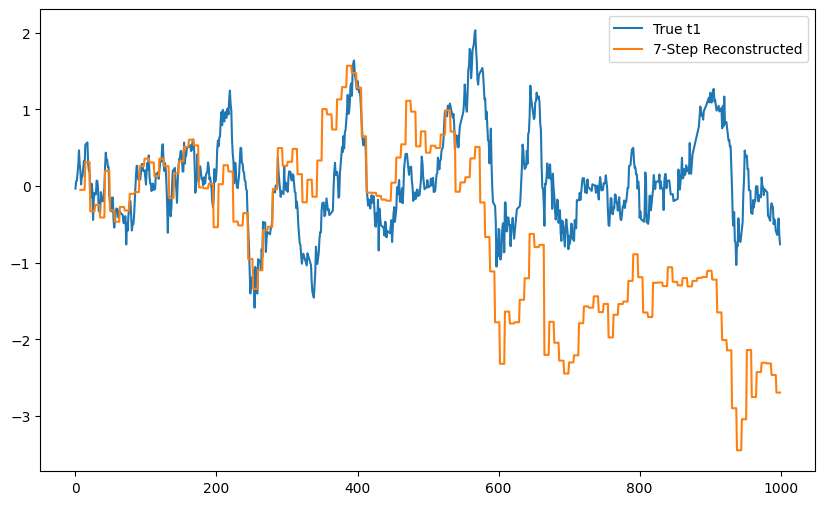

In [49]:
import matplotlib.pyplot as plt

seq = df_valid["seq_ix"].unique()[0]
g = df_valid[df_valid["seq_ix"] == seq]

plt.figure(figsize=(10,6))
plt.plot(g["step_in_seq"], g["t1"], label="True t1")
plt.plot(g["step_in_seq"], g["t1_reconstructed"], label="7-Step Reconstructed")
plt.legend()
plt.show()

In [50]:
score = weighted_pearson_correlation(
    df_valid["t1"],
    df_valid["t1_reconstructed"]
)

print("Block reconstruction score:", score)

Block reconstruction score: -0.04144134880402433


In [32]:
df.loc[[0,1 ,2 ,3, 4,5,6,7,8,9,10,11,12,13,14,15, 16, 17,18,19,20] ,"t1_new"] = 1

In [30]:
df[['t1', 't1_new']].head(20)

,t1,t1_new
0,1.864018,1
1,2.168843,1
2,2.459723,1
3,2.272444,1
4,2.324245,1
5,2.384014,1
6,2.547385,1
7,2.583247,1
8,2.499569,1
9,2.057273,1


In [33]:
weighted_pearson_correlation(df['t1'], df['t1_new'])

0.0015796872975903204

In [34]:
df["dt1"] = df.groupby("seq_ix")["t1"].diff()

# Drop first rows of each sequence (dt1 = NaN)
df_train = df[df["dt1"].notna()]